## Stock Prices with PySpark

In [1]:
from pyspark.sql import SparkSession, functions

In [2]:
spark = SparkSession.builder.appName("stock_price_analysis").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/05 22:18:42 WARN Utils: Your hostname, aditya-HP-Laptop-15s-eq1xxx, resolves to a loopback address: 127.0.1.1; using 10.103.210.123 instead (on interface wlo1)
26/05/05 22:18:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/05 22:18:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'GOOG', 'TSLA', 'SPY', 'GS', 'F']

data = yf.download(tickers, start='2022-02-01', end='2026-02-01')
# data = data.droplevel(1, axis=1)
# data = data.reset_index()
data

[*********************100%***********************]  7 of 7 completed


Price            Close                                                 \
Ticker            AAPL          F        GOOG          GS        MSFT   
Date                                                                    
2022-02-01  170.862488  15.666066  136.755737  327.238373  298.070618   
2022-02-02  172.066086  15.643317  146.831024  326.339508  302.607849   
2022-02-03  169.189148  15.082190  141.488892  322.582245  290.820526   
2022-02-04  168.905045  13.618709  141.851410  330.420380  295.348206   
2022-02-07  168.189819  13.565631  137.806625  330.914673  290.531006   
...                ...        ...         ...         ...         ...   
2026-01-26  255.171234  13.296000  333.355164  926.981506  469.209045   
2026-01-27  258.028534  13.780750  334.764160  924.852722  479.485596   
2026-01-28  256.200287  13.671928  336.043274  931.905640  480.533203   
2026-01-29  258.038544  13.850000  338.421600  935.198303  432.512817   
2026-01-30  259.237427  13.731286  338.291687  930.512939  429.310120   

Price                                     High                         ...  \
Ticker             SPY        TSLA        AAPL          F        GOOG  ...   
Date                                                                   ...   
2022-02-01  427.287262  310.416656  171.087547  15.810140  137.074622  ...   
2022-02-02  431.438019  301.886658  172.105236  15.961795  150.861442  ...   
2022-02-03  421.297058  297.046661  172.457475  15.635735  147.903438  ...   
2022-02-04  423.278046  307.773346  170.580483  14.096426  143.358280  ...   
2022-02-07  421.919678  302.446655  170.433519  13.740036  142.675148  ...   
...                ...         ...         ...        ...         ...  ...   
2026-01-26  690.843262  435.200012  256.320153  13.513643  336.113230  ...   
2026-01-27  693.595764  430.899994  261.705117  13.800535  337.976893  ...   
2026-01-28  693.525940  431.459991  258.618008  13.741179  337.392330  ...   
2026-01-29  692.149719  416.559998  259.407258  13.939036  342.049050  ...   
2026-01-30  690.085327  430.410004  261.655147  13.830214  340.050458  ...   

Price             Open                            Volume                       \
Ticker            MSFT         SPY        TSLA      AAPL          F      GOOG   
Date                                                                            
2022-02-01  299.663488  425.145855  311.736664  86213900  117651800  51204000   
2022-02-02  298.910459  429.692828  309.393341  84914300   95377600  89750000   
2022-02-03  298.775242  425.400607  294.000000  89418100  103016000  56930000   
2022-02-04  289.816570  421.061184  299.073334  82465400  211100500  49224000   
2022-02-07  295.570289  424.042200  307.929993  77251200   84610000  44610000   
...                ...         ...         ...       ...        ...       ...   
2026-01-26  464.250362  688.609372  445.000000  55969200   59171000  18502500   
2026-01-27  472.621289  692.289334  437.410004  49648300  100003700  16080900   
2026-01-28  482.109592  695.151505  431.910004  41288000   48751800  17538500   
2026-01-29  438.988028  694.493355  437.799988  67253000   84803900  24548300   
2026-01-30  438.169902  689.905825  425.350006  92443400   66996300  21740200   

Price                                                
Ticker           GS       MSFT        SPY      TSLA  
Date                                                 
2022-02-01  3303700   40950400  123155400  73138200  
2022-02-02  2742400   36636000  117361000  66792900  
2022-02-03  2372900   43730000  118024400  78855600  
2022-02-04  3762300   35096500  118454400  73625400  
2022-02-07  2635600   28533300   84472900  60994500  
...             ...        ...        ...       ...  
2026-01-26  2655900   29291200   60473800  49397400  
2026-01-27  2012500   29213900   55506100  37733100  
2026-01-28  1674100   36875400   61172200  54857400  
2026-01-29  2335400  128855300   97486200  81686100  
2026-01-30  1893700   58566800  101835100  8262

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore')

In [5]:
data.xs('AAPL', axis=1, level=1)

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-02-01,170.862488,171.087547,168.611848,170.275359,86213900
2022-02-02,172.066086,172.105236,169.609961,170.999483,84914300
2022-02-03,169.189148,172.457475,168.425890,170.735239,89418100
2022-02-04,168.905045,170.580483,167.229607,168.209391,82465400
2022-02-07,168.189819,170.433519,167.494166,169.365558,77251200
...,...,...,...,...,...
2026-01-26,255.171234,256.320153,249.566478,251.244900,55969200
2026-01-27,258.028534,261.705117,257.968592,258.927717,49648300
2026-01-28,256.200287,258.618008,254.272083,257.409147,41288000


In [6]:
combined_df = pd.DataFrame()
for ticker in tickers:
    df = data.xs(ticker, axis=1, level=1)  # cross section
    df['Symbol'] = ticker
    # Sector
    if ticker in ['MSFT', 'AAPL', 'GOOG']:
        df['Sector'] = 'Information Technology'
    elif ticker in ['SPY', 'GS']:
        df['Sector'] = 'Finance'
    elif ticker in ['TSLA', 'F']:
        df['Sector'] = 'Automobile'
    # Industry
    if ticker in ['MSFT', 'AAPL', 'GOOG']:
        df['Industry'] = 'Electronics'
    elif ticker in ['SPY', 'GS']:
        df['Industry'] = 'Banking'
    elif ticker in ['TSLA', 'F']:
        df['Industry'] = 'Manufacturing'
    df = df.reset_index()
    combined_df = pd.concat([df, combined_df], axis=0)

In [7]:
combined_df

Price,Date,Close,High,Low,Open,Volume,Symbol,Sector,Industry
0,2022-02-01,15.666066,15.810140,15.104939,15.628153,117651800,F,Automobile,Manufacturing
1,2022-02-02,15.643317,15.961795,15.302092,15.779808,95377600,F,Automobile,Manufacturing
2,2022-02-03,15.082190,15.635735,15.067025,15.294508,103016000,F,Automobile,Manufacturing
3,2022-02-04,13.618709,14.096426,13.285066,14.043346,211100500,F,Automobile,Manufacturing
4,2022-02-07,13.565631,13.740036,13.421559,13.444306,84610000,F,Automobile,Manufacturing
...,...,...,...,...,...,...,...,...,...
998,2026-01-26,255.171234,256.320153,249.566478,251.244900,55969200,AAPL,Information Technology,Electronics
999,2026-01-27,258.028534,261.705117,257.968592,258.927717,49648300,AAPL,Information Technology,Electronics
1000,2026-01-28,256.200287,258.618008,254.272083,257.409147,41288000,AAPL,Information Technology,Electronics
1001,2026-01-29,258.038544,259.407258,254.172166,257.758807,67253000,AAPL,Information Technology,Electronics


In [8]:
df = spark.createDataFrame(combined_df)

In [9]:
df.printSchema()

root
 |-- Date: timestamp (nullable = true)
 |-- Close: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Open: double (nullable = true)
 |-- Volume: long (nullable = true)
 |-- Symbol: string (nullable = true)
 |-- Sector: string (nullable = true)
 |-- Industry: string (nullable = true)



In [10]:
df.show()

[Stage 0:>                                                          (0 + 1) / 1]

+-------------------+------------------+------------------+------------------+------------------+---------+------+----------+-------------+
|               Date|             Close|              High|               Low|              Open|   Volume|Symbol|    Sector|     Industry|
+-------------------+------------------+------------------+------------------+------------------+---------+------+----------+-------------+
|2022-02-01 00:00:00| 15.66606616973877|15.810139788364918|15.104939090089694|15.628152744665579|117651800|     F|Automobile|Manufacturing|
|2022-02-02 00:00:00|15.643317222595215| 15.96179491015011|15.302092058553548|15.779807866733664| 95377600|     F|Automobile|Manufacturing|
|2022-02-03 00:00:00|15.082189559936523|15.635735089324468|15.067025058300564|15.294508492188365|103016000|     F|Automobile|Manufacturing|
|2022-02-04 00:00:00|13.618708610534668|14.096425838171092|13.285066439507741|14.043346467612462|211100500|     F|Automobile|Manufacturing|
|2022-02-07 00:00:00

Traceback (most recent call last):
  File "/home/aditya/miniconda3/envs/pyspark_env/lib/python3.10/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
  File "/home/aditya/miniconda3/envs/pyspark_env/lib/python3.10/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
BrokenPipeError: [Errno 32] Broken pipe
                                                                                

In [11]:
df.describe().toPandas()

26/05/05 22:18:56 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,Close,High,Low,Open,Volume,Symbol,Sector,Industry
0,count,7021,7021,7021,7021,7021,7021,7021,7021
1,mean,275.9681793620929,278.90028467069044,272.8341001673634,275.8602854804533,5.1694397393533684E7,None,None,None
2,stddev,184.1591636676679,185.51562448039084,182.61958304974334,184.06739523770884,4.180384376252586E7,None,None,None
3,min,8.265386581420898,8.496011026981696,8.027602156011103,8.084670819734272,460100,AAPL,Automobile,Banking
4,max,970.7511596679688,979.5449183976932,951.9899210781169,967.9061580031429,479840300,TSLA,Information Technology,Manufacturing


In [12]:
df.count()

7021

In [13]:
df.distinct().count()

7021

In [14]:
df.select(['Open', 'High', 'Low', 'Close', 'Volume']).describe().show()

+-------+------------------+------------------+------------------+-----------------+--------------------+
|summary|              Open|              High|               Low|            Close|              Volume|
+-------+------------------+------------------+------------------+-----------------+--------------------+
|  count|              7021|              7021|              7021|             7021|                7021|
|   mean| 275.8602854804533|278.90028467069044| 272.8341001673634|275.9681793620929|5.1694397393533684E7|
| stddev|184.06739523770884|185.51562448039084|182.61958304974334|184.1591636676679| 4.180384376252586E7|
|    min| 8.084670819734272| 8.496011026981696| 8.027602156011103|8.265386581420898|              460100|
|    max| 967.9061580031429| 979.5449183976932| 951.9899210781169|970.7511596679688|           479840300|
+-------+------------------+------------------+------------------+-----------------+--------------------+



In [15]:
df.groupBy('Sector').count().show()

+--------------------+-----+
|              Sector|count|
+--------------------+-----+
|             Finance| 2006|
|          Automobile| 2006|
|Information Techn...| 3009|
+--------------------+-----+



In [16]:
by_sector = df.select(['Open', 'Close', 'Symbol', 'Sector']).groupBy('Sector').mean().collect()

In [17]:
print(['Symbol', 'Open', 'Close'])
for row in by_sector:
    print(list(row), end="\n")

['Symbol', 'Open', 'Close']
['Finance', 469.72188193133456, 470.0049537057772]
['Automobile', 139.87191125664233, 139.79917277415038]
['Information Technology', 237.2781373290722, 237.38966752493172]


In [18]:
sector_df = df.select(['Open', 'Close', 'Symbol', 'Sector']).groupBy('Sector').mean().toPandas()
sector_df

,Sector,avg(Open),avg(Close)
0,Finance,469.721882,470.004954
1,Automobile,139.871911,139.799173
2,Information Technology,237.278137,237.389668


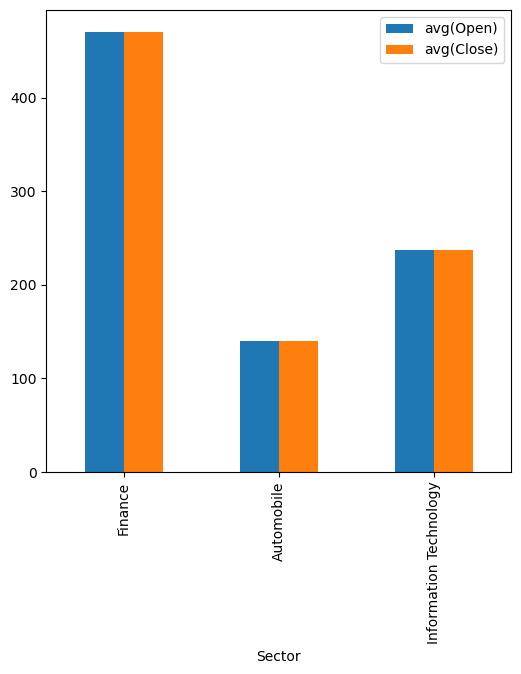

In [30]:
sector_df.plot(kind="bar", 
               x='Sector', 
               y=sector_df.columns.tolist()[1:],
               figsize=(6,6))
plt.show()

In [31]:
industry_df = df.select(['Industry', 'Open', 'Close']).groupBy('Industry').mean().toPandas()

In [32]:
industry_df

,Industry,avg(Open),avg(Close)
0,Banking,469.721882,470.004954
1,Manufacturing,139.871911,139.799173
2,Electronics,237.278137,237.389668


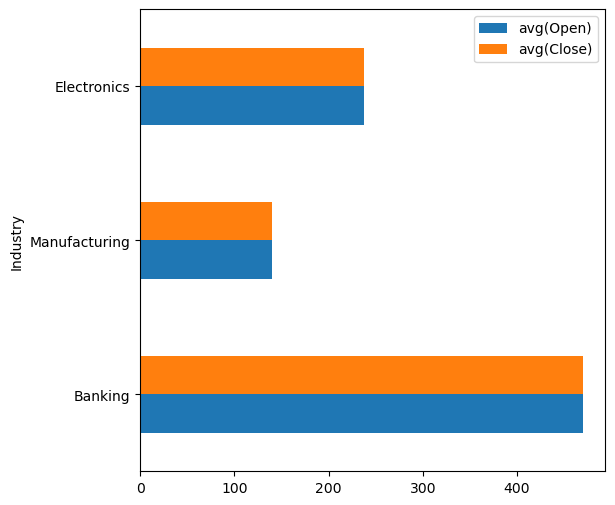

In [33]:
industry_df.plot(kind='barh', 
                 x='Industry', 
                 y=industry_df.columns.tolist()[1:], 
                 figsize=(6,6))
plt.show()